## Figure 3 — Biological Signal Preservation After Ambient RNA Correction

Evaluates whether ambient RNA removal tools preserve or distort biological signal
across three real-world datasets (PBMC, WBC, PFC) using three complementary readouts:
marker gene enrichment, cell type classification confidence, and cell type composition stability.

### Required files (all under `figure_3_data/`)
**PBMC:**
- `pbmc_confidence_scores.csv`, `pbmc_confidence_scores_fine.csv`
- `pbmc_number_confident_cells.csv`, `pbmc_number_confident_cells_fine.csv`
- `pbmc_enrichment_ratios.csv`

**WBC:**
- `wbc_confidence_scores.csv`, `wbc_confidence_scores_fine.csv`
- `wbc_number_confident_cells.csv`, `wbc_number_confident_cells_fine.csv`
- `wbc_enrichment_ratios.csv`

**PFC:**
- `pfc_confidence_scores.csv`
- `pfc_enrichment_ratios.csv`, `pfc_number_confident_cells.csv`

> Note: PFC has no fine-grained confidence model. Fine-grained WBC/PBMC cell type counts
> for the supplement heatmap (Fig_S) are hardcoded from scType annotations — no additional files needed.

### Figures produced
- **Fig_3A_enrichment.png** — Marker gene log₂ fold enrichment per tool and dataset (Friedman + pairwise Wilcoxon)
- **Fig_3B_confidence.png** — Cell type classification confidence score distributions (coarse + fine models)
- **Fig_3C_celltype_heatmap.png** — Cell type abundance changes relative to uncorrected (coarse, all datasets)
- **Fig_S_celltype_fine.png** — Cell type abundance changes for fine-grained annotations (PBMC + WBC supplement)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

BASE = Path('figure_3_data')
plt.rcParams['font.family'] = 'Arial'

TOOL_COLORS = {
    'Uncorrected': '#808080',
    'CellBender':  '#2E86AB',
    'DecontX':     '#A23B72',
    'DecontX°':    '#C97C9E',
    'SoupX':       '#F18F01',
    'scCDC' : '#3BB273' ,
    'scAR':        '#C73E1D',
    'CellClear':   '#6A4C93'
}
tool_order = ['CellBender',  'DecontX', 'SoupX', 'scCDC', 'scAR']
GREY_TOOLS  = ['scAR', 'CellClear']
VALID_TOOLS = ['CellBender', 'DecontX', 'DecontX°', 'SoupX', 'scCDC']

In [2]:
datasets = {
    'pbmc': {
        'confidence':      pd.read_csv(BASE / 'pbmc_confidence_scores.csv',      index_col=0),
        'enrichment':      pd.read_csv(BASE / 'pbmc_enrichment_ratios.csv',       index_col=0),
        'n_confident':     pd.read_csv(BASE / 'pbmc_number_confident_cells.csv'),
        'confidence_fine': pd.read_csv(BASE / 'pbmc_confidence_scores_fine.csv'),
        'n_confident_fine':     pd.read_csv(BASE / 'pbmc_number_confident_cells_fine.csv'),
        
    },
    'wbc': {
        'confidence':      pd.read_csv(BASE / 'wbc_confidence_scores.csv',        index_col=0),
        'enrichment':      pd.read_csv(BASE / 'wbc_enrichment_ratios.csv',         index_col=0),
        'n_confident':     pd.read_csv(BASE / 'wbc_number_confident_cells.csv'),
        'confidence_fine': pd.read_csv(BASE / 'wbc_confidence_scores_fine.csv'),
        'n_confident_fine':     pd.read_csv(BASE / 'wbc_number_confident_cells_fine.csv'),
        
    },
    'pfc': {
        'confidence':  pd.read_csv(BASE / 'pfc_confidence_scores.csv',  index_col=0),
        'enrichment':  pd.read_csv(BASE / 'pfc_enrichment_ratios.csv',   index_col=0),
        'n_confident': pd.read_csv(BASE / 'pfc_number_confident_cells.csv')
    }
}

# Standardize confidence score column name and remove "all cells" QC rows
for name, data in datasets.items():
    for key in ['confidence', 'confidence_fine']:
        if key not in data: continue
        col = [c for c in data[key].columns if 'conf_score' in c][0]
        data[key].rename(columns={col: 'confidence_score'}, inplace=True)
    data['enrichment_clean'] = data['enrichment'][
        ~data['enrichment']['Zelltyp'].str.contains('all cells', case=False)
    ].copy()

In [3]:
def cliffs_delta(u_stat, n1, n2):
    return (2 * u_stat - n1 * n2) / (n1 * n2)

friedman_results = {}
conf_results     = {}

# ── Enrichment ────────────────────────────────────────────────────────────────
for dataset_name, data in datasets.items():
    pivot = data['enrichment_clean'].pivot_table(index='Marker', columns='Tool', values='log2fold')
    test_tools = ['CellBender','DecontX','DecontX°','SoupX', 'scCDC'] if dataset_name == 'wbc' \
                 else ['CellBender','DecontX','SoupX', 'scCDC']
    pivot = pivot[[t for t in test_tools if t in pivot.columns]]

    stat, p = friedmanchisquare(*[pivot[t].values for t in pivot.columns])
    friedman_results[dataset_name] = {'stat': stat, 'p': p, 'pivot': pivot,
                                       'tools': list(pivot.columns)}
    print(f"{dataset_name.upper()} Friedman: χ²={stat:.3f}, p={p:.4f}")

    # Pairwise Wilcoxon between valid tools
    print(f"  Pairwise (two-sided):")
    for t1, t2 in combinations(pivot.columns, 2):
        paired = pivot[[t1, t2]].dropna()
        _, pw = wilcoxon(paired[t1].values, paired[t2].values)
        print(f"    {t1} vs {t2}: p={pw:.4f}")

# ── Confidence scores ─────────────────────────────────────────────────────────
for dataset_name, data in datasets.items():
    for model_type in (['coarse','fine'] if 'confidence_fine' in data else ['coarse']):
        conf = data['confidence_fine'] if model_type == 'fine' else data['confidence']
        test_tools = ['CellBender','DecontX','DecontX°','SoupX', 'scCDC'] if dataset_name == 'wbc' \
                     else ['CellBender','DecontX','SoupX', 'scCDC']

        uncorr = conf[conf['Tool'] == 'Uncorrected']['confidence_score'].values
        pairwise = []
        for tool in test_tools:
            tool_data = conf[conf['Tool'] == tool]['confidence_score'].values
            diff = np.median(tool_data) - np.median(uncorr)
            alt  = 'two-sided' if diff < 0 else 'greater'
            stat, p = mannwhitneyu(tool_data, uncorr, alternative=alt)
            pairwise.append({'tool': tool, 'n_cells': len(tool_data),
                             'median': np.median(tool_data), 'median_diff': diff,
                             'cliffs_delta': cliffs_delta(stat, len(tool_data), len(uncorr)),
                             'p_raw': p})

        _, pvals_corr, _, _ = multipletests([r['p_raw'] for r in pairwise], method='bonferroni')
        for r, pc in zip(pairwise, pvals_corr):
            r['p_corrected'] = pc
        conf_results[f"{dataset_name}_{model_type}"] = pairwise

PBMC Friedman: χ²=18.467, p=0.0004
  Pairwise (two-sided):
    CellBender vs DecontX: p=0.0742
    CellBender vs SoupX: p=0.0078
    CellBender vs scCDC: p=0.0039
    DecontX vs SoupX: p=0.0195
    DecontX vs scCDC: p=0.0117
    SoupX vs scCDC: p=0.0039
WBC Friedman: χ²=13.600, p=0.0087
  Pairwise (two-sided):
    CellBender vs DecontX: p=0.0742
    CellBender vs DecontX°: p=0.4258
    CellBender vs SoupX: p=0.1289
    CellBender vs scCDC: p=0.0547
    DecontX vs DecontX°: p=0.0742
    DecontX vs SoupX: p=0.0078
    DecontX vs scCDC: p=0.0273
    DecontX° vs SoupX: p=0.0977
    DecontX° vs scCDC: p=0.0391
    SoupX vs scCDC: p=0.0742
PFC Friedman: χ²=23.133, p=0.0000
  Pairwise (two-sided):
    CellBender vs DecontX: p=0.0391
    CellBender vs SoupX: p=0.0039
    CellBender vs scCDC: p=0.0039
    DecontX vs SoupX: p=0.0078
    DecontX vs scCDC: p=0.0039
    SoupX vs scCDC: p=0.0039


In [4]:
rows = []
for key, pairwise in conf_results.items():
    dataset, model = key.rsplit('_', 1)
    uncorr_n = len(datasets[dataset][
        'confidence_fine' if model == 'fine' else 'confidence'
    ][lambda df: df['Tool'] == 'Uncorrected']['confidence_score'])
    
    for r in pairwise:
        rows.append({
            'Dataset': dataset.upper(),
            'Model': model,
            'Tool': r['tool'],
            'N cells': r['n_cells'],
            'Median confidence': round(r['median'], 6),
            'Δ Median': round(r['median_diff'], 4),
            "Cliff's δ": round(r['cliffs_delta'], 3),
            'p (Bonferroni)': r['p_corrected'],
            'Significance': '**' if r['p_corrected'] < 0.01 else
                            '*'  if r['p_corrected'] < 0.05 else 'ns'
        })

pd.DataFrame(rows)

,Dataset,Model,Tool,N cells,Median confidence,Δ Median,Cliff's δ,p (Bonferroni),Significance
0,PBMC,coarse,CellBender,41428,0.999999,0.0000,0.144,8.622045e-268,**
1,PBMC,coarse,DecontX,38362,0.999999,0.0000,0.145,5.051705e-263,**
2,PBMC,coarse,SoupX,37560,0.999998,0.0000,0.073,2.862934e-66,**
3,PBMC,coarse,scCDC,38436,0.999992,-0.0000,-0.068,6.461719e-59,**
4,PBMC,fine,CellBender,41428,0.999430,0.0011,0.130,1.951922e-219,**
5,PBMC,fine,DecontX,38362,0.999064,0.0008,0.073,3.228091e-68,**
6,PBMC,fine,SoupX,37560,0.998975,0.0007,0.061,1.151432e-46,**
7,PBMC,fine,scCDC,38436,0.996750,-0.0016,-0.065,2.265562e-53,**
8,WBC,coarse,CellBender,118951,0.998792,0.0003,0.056,3.035085e-123,**
9,WBC,coarse,DecontX,121114,0.998734,0.0002,0.022,2.840209e-20,**


/home/luschroe/miniconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/luschroe/miniconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


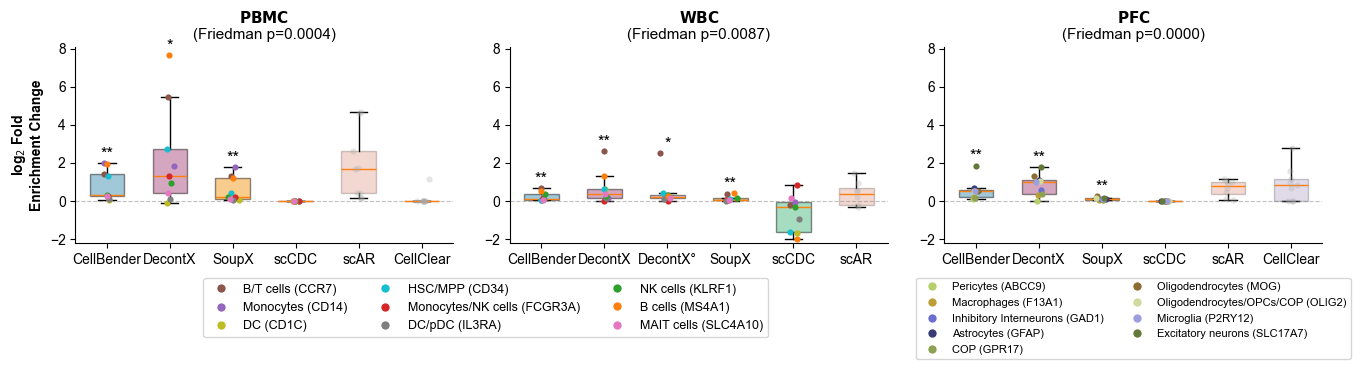

In [5]:
# Build consistent scenario color palettes across datasets
pbmc_wbc_scen = pd.concat([datasets[d]['enrichment'][['Marker','Zelltyp']].drop_duplicates()
                            for d in ['pbmc','wbc']]).drop_duplicates()
pbmc_wbc_scen['label'] = pbmc_wbc_scen['Zelltyp'] + ' (' + pbmc_wbc_scen['Marker'].str.split(' ').str[0] + ')'
shared_palette = dict(zip(pbmc_wbc_scen['label'].unique(),
                          sns.color_palette('tab10', len(pbmc_wbc_scen['label'].unique()))))

pfc_scen = datasets['pfc']['enrichment'][['Marker','Zelltyp']].drop_duplicates()
pfc_scen['label'] = pfc_scen['Zelltyp'] + ' (' + pfc_scen['Marker'].str.split(' ').str[0] + ')'
pfc_palette = dict(zip(pfc_scen['label'].unique(),
                       sns.color_palette('tab20b', len(pfc_scen['label'].unique()))))
scenario_palette = {**shared_palette, **pfc_palette}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
pbmc_seen_labels = {}

for idx, dataset_name in enumerate(['pbmc','wbc','pfc']):
    ax   = axes[idx]
    res  = friedman_results[dataset_name]
    pivot = datasets[dataset_name]['enrichment_clean'].pivot_table(
        index='Marker', columns='Tool', values='log2fold')
    tool_order = (['CellBender','DecontX','DecontX°','SoupX', 'scCDC','scAR'] if dataset_name == 'wbc'
                  else ['CellBender','DecontX','SoupX', 'scCDC','scAR','CellClear'])
    available  = [t for t in tool_order if t in pivot.columns]    
    pivot = pivot[available]
    
    scen_df = pfc_scen if dataset_name == 'pfc' else pbmc_wbc_scen

    bp = ax.boxplot([pivot[t].dropna().values for t in available],
                    tick_labels=available, patch_artist=True, widths=0.55, showfliers=False)

    seen_labels = {}
    for i, (tool, patch) in enumerate(zip(available, bp['boxes'])):
        grey = tool in GREY_TOOLS
        patch.set_facecolor(TOOL_COLORS[tool])
        patch.set_alpha(0.2 if grey else 0.45)

        for marker_label, val in pivot[tool].dropna().items():
            match = scen_df[scen_df['Marker'].str.startswith(marker_label.split(' ')[0])]
            label = match['label'].values[0] if len(match) else 'unknown'
            sc_color = '#aaaaaa' if grey else scenario_palette.get(label, 'black')
            ax.scatter(np.random.normal(i+1, 0.04, 1), val,
                       alpha=0.3 if grey else 1.0, s=20, color=sc_color, zorder=3, linewidths=0,
                       label=label if (not grey and label not in seen_labels) else '_nolegend_')
            if not grey: seen_labels[label] = sc_color

        # Significance vs 0 (one-sided Wilcoxon, Bonferroni-corrected for n tools)
        if not grey and tool in res['tools']:
            vals = pivot[tool].dropna().values
            if len(vals) >= 6:
                _, p = wilcoxon(vals, alternative='greater')
                res[tool+'_vs_zero'] = _, p
                p_corr = min(p * len([t for t in available if t not in GREY_TOOLS]), 1.0)
                sig = '***' if p_corr < 0.001 else '**' if p_corr < 0.01 else '*' if p_corr < 0.05 else ''
                ax.text(i+1, np.nanmax(vals)+0.08, sig, ha='center', va='bottom', fontsize=12)

    # Legends
    if idx == 0:
        pbmc_seen_labels = dict(seen_labels)
    elif idx == 1:
        combined = {**pbmc_seen_labels, **seen_labels}
        handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=7, label=l)
                   for l, c in combined.items()]
        axes[0].legend(handles=handles, loc='upper right', bbox_to_anchor=(1.85,-0.15),
                       ncol=3, fontsize=9, frameon=True)
    elif idx == 2 and seen_labels:
        handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=7, label=l)
                   for l, c in seen_labels.items()]
        ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5,-0.15),
                  ncol=2, fontsize=8, frameon=True)

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_ylabel('log$_2$ Fold\nEnrichment Change' if idx == 0 else '', fontsize=10, weight='bold')
    ax.set_title(f"$\\bf{{{dataset_name.upper()}}}$\n(Friedman p={res['p']:.4f})", fontsize=11)
    ax.spines[['top','right']].set_visible(False)

ymax = max(ax.get_ylim()[1] for ax in axes)
ymin = min(ax.get_ylim()[0] for ax in axes)
for ax in axes: ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.subplots_adjust(wspace=0.15, bottom=0.38)
plt.savefig(BASE / 'Fig_3A_enrichment.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

rows = []
for dataset_name, data in datasets.items():
    res = friedman_results[dataset_name]
    pivot = data['enrichment_clean'].pivot_table(
        index='Marker', columns='Tool', values='log2fold')
    test_tools = (['CellBender','DecontX','DecontX°','SoupX','scCDC']
                  if dataset_name == 'wbc'
                  else ['CellBender','DecontX','SoupX','scCDC'])
    available = [t for t in test_tools if t in pivot.columns]

    raw_ps, tool_rows = [], []
    for tool in available:
        vals = pivot[tool].dropna().values
        _, p = wilcoxon(vals, alternative='greater')
        raw_ps.append(p)
        tool_rows.append({'Dataset': dataset_name.upper(),
                          'Friedman χ²': round(res['stat'], 3),
                          'Friedman p': round(res['p'], 4),
                          'Tool': tool, 'n': len(vals),
                          'Median log2FC': round(np.median(vals), 3),
                          'p_raw': p})

    _, p_corr, _, _ = multipletests(raw_ps, method='fdr_bh')
    for r, pc in zip(tool_rows, p_corr):
        r['p (BH)'] = round(pc, 4)
        r['Sig'] = '**' if pc < 0.01 else '*' if pc < 0.05 else 'ns'
        rows.append(r)

pd.DataFrame(rows).drop(columns='p_raw')

/home/luschroe/miniconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
/home/luschroe/miniconda3/lib/python3.12/site-packages/scipy/stats/_wilcoxon.py:172: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,Dataset,Friedman χ²,Friedman p,Tool,n,Median log2FC,p (BH),Sig
0,PBMC,18.467,0.0004,CellBender,9,0.332,0.0039,**
1,PBMC,18.467,0.0004,DecontX,9,1.298,0.0078,**
2,PBMC,18.467,0.0004,SoupX,9,0.217,0.0039,**
3,PBMC,18.467,0.0004,scCDC,9,0.000,1.0000,ns
4,WBC,13.600,0.0087,CellBender,9,0.097,0.0033,**
5,WBC,13.600,0.0087,DecontX,9,0.347,0.0033,**
6,WBC,13.600,0.0087,DecontX°,9,0.191,0.0049,**
7,WBC,13.600,0.0087,SoupX,9,0.065,0.0033,**
8,WBC,13.600,0.0087,scCDC,9,-0.319,0.9727,ns
9,PFC,23.133,0.0000,CellBender,9,0.528,0.0026,**


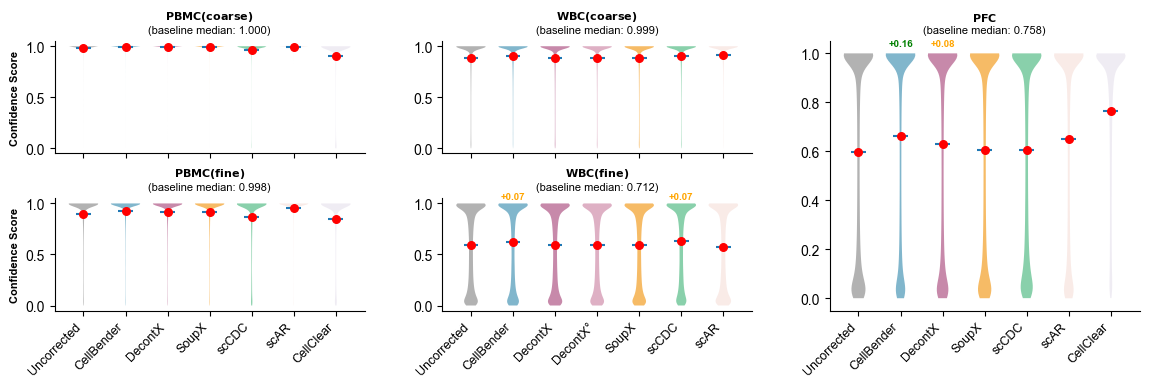

In [7]:
fig = plt.figure(figsize=(14, 3.5))
gs  = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.25)

plot_configs = [
    ('pbmc', 'coarse', gs[0, 0]),
    ('pbmc', 'fine',   gs[1, 0]),
    ('wbc',  'coarse', gs[0, 1]),
    ('wbc',  'fine',   gs[1, 1]),
    ('pfc',  'coarse', gs[:, 2]),
]

for dataset_name, model_type, grid_pos in plot_configs:
    ax   = fig.add_subplot(grid_pos)
    conf = datasets[dataset_name].get('confidence_fine') if model_type == 'fine' \
           else datasets[dataset_name]['confidence']
    if conf is None: continue

    tool_order = (['Uncorrected','CellBender','DecontX','DecontX°','SoupX', 'scCDC','scAR']
                  if dataset_name == 'wbc'
                  else ['Uncorrected','CellBender','DecontX','SoupX', 'scCDC','scAR','CellClear'])
    plot_data = conf[conf['Tool'].isin(tool_order)]

    parts = ax.violinplot(
        [plot_data[plot_data['Tool']==t]['confidence_score'].values for t in tool_order],
        positions=range(len(tool_order)), widths=0.7, showmeans=True, showextrema=False)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(TOOL_COLORS[tool_order[i]])
        pc.set_alpha(0.1 if tool_order[i] in GREY_TOOLS else 0.6)

    means = [plot_data[plot_data['Tool']==t]['confidence_score'].mean() for t in tool_order]
    ax.scatter(range(len(tool_order)), means, color='red', s=30, zorder=3)

    uncorr_median = plot_data[plot_data['Tool']=='Uncorrected']['confidence_score'].median()
    for i, tool in enumerate(tool_order):
        if tool in ['Uncorrected'] + GREY_TOOLS: continue
        diff = plot_data[plot_data['Tool']==tool]['confidence_score'].median() - uncorr_median
        if abs(diff) > 0.05:
            ax.text(i, 1.02, f'{diff:+.2f}', ha='center', va='bottom', fontsize=7,
                    fontweight='bold', color='green' if diff > 0.10 else 'orange')

    ax.set_xticks(range(len(tool_order)))
    # Hide x labels for upper-row non-spanning subplots
    if hasattr(grid_pos, 'rowspan') and grid_pos.rowspan.start == 0 and grid_pos.rowspan.stop == 1:
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(tool_order, rotation=45, ha='right', fontsize=9)
    if grid_pos.colspan.start == 0:
        ax.set_ylabel('Confidence Score', fontsize=8, weight='bold')
    model_label = ' (fine)' if model_type == 'fine' else ('' if dataset_name == 'pfc' else ' (coarse)')
    ax.set_title(f"$\\bf{{{dataset_name.upper()}{model_label}}}$\n(baseline median: {uncorr_median:.3f})", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.spines[['top','right']].set_visible(False)

plt.savefig(BASE / 'Fig_3B_confidence.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
celltype_changes = []

for d in ['pbmc', 'wbc', 'pfc']:
    datasets[d]['n_confident']['Total_Confident'] = datasets[d]['n_confident'].drop(columns='Tool').sum(axis=1)

for dataset_name, data in datasets.items():
    n_conf = data['n_confident']
    celltypes = [c for c in n_conf.columns if c != 'Tool']
    uncorr = n_conf[n_conf['Tool'] == 'Uncorrected'][celltypes].iloc[0].fillna(0)

    for _, row in n_conf[n_conf['Tool'] != 'Uncorrected'].iterrows():
        for ct in celltypes:
            u, c = float(uncorr[ct]), float(row[ct]) if not pd.isna(row[ct]) else 0.0
            if   u == 0 and c > 0: change = 'Gain'
            elif u > 0 and c == 0: change = 'Loss'
            elif abs(c - u) / max(u, 1) > 0.05: change = 'Changed (>5%)'
            else:                  change = 'Stable'
            celltype_changes.append({'Dataset': dataset_name.upper(), 'Tool': row['Tool'],
                                     'Cell_Type': ct, 'Uncorrected': int(u), 'Corrected': int(c),
                                     'Change_Type': change, 'Pct_Change': (c-u)/max(u,1)*100})

changes_df = pd.DataFrame(celltype_changes)
changes_df.to_csv(BASE / 'celltype_changes.csv', index=False)
print(changes_df.groupby(['Dataset','Tool','Change_Type']).size().unstack(fill_value=0))

Change_Type         Changed (>5%)  Gain  Loss  Stable
Dataset Tool                                         
PBMC    CellBender              7     0     1       1
        CellClear               4     0     0       5
        DecontX                 3     0     0       6
        SoupX                   0     0     0       9
        scAR                    3     0     1       5
        scCDC                   2     0     0       7
PFC     CellBender             11     0     0       2
        CellClear              13     0     0       0
        DecontX                12     0     0       1
        SoupX                   0     0     0      13
        scAR                   12     0     1       0
        scCDC                   7     0     0       6
WBC     CellBender              7     2     0       5
        DecontX                 6     1     1       6
        DecontX°                7     1     0       6
        SoupX                   4     1     0       9
        scAR                

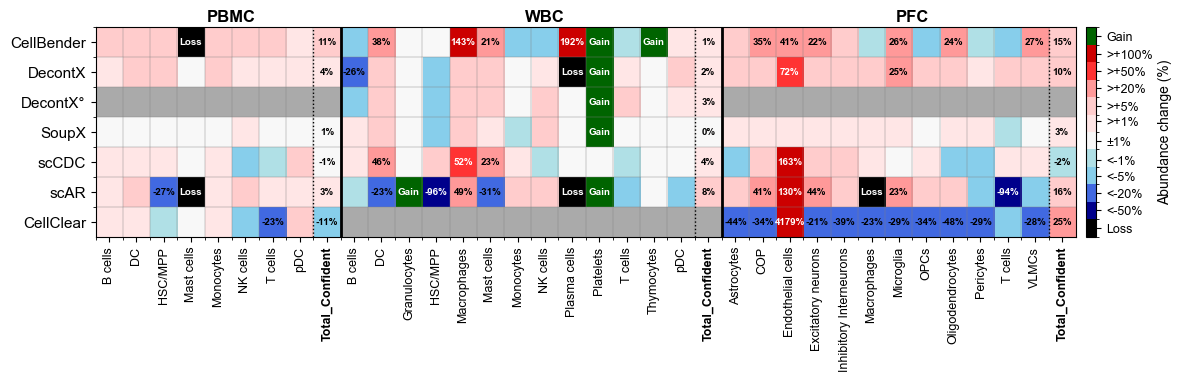

In [9]:
def build_heatmap(changes_df, dataset_list, method_order, na_tools_per_dataset):
    """Build matrix and text annotations for the heatmap."""
    all_celltypes, dataset_positions = [], []
    for ds in dataset_list:
        sub = changes_df[changes_df['Dataset'] == ds.upper()]
        cts = sorted([c for c in sub['Cell_Type'].unique() if c != 'Total_Confident'])
        if 'Total_Confident' in sub['Cell_Type'].unique(): cts.append('Total_Confident')
        dataset_positions.append((len(all_celltypes), ds.upper(), len(cts)))
        all_celltypes.extend(cts)

    matrix = np.full((len(method_order), len(all_celltypes)), np.nan)
    text   = [[''] * len(all_celltypes) for _ in range(len(method_order))]
    col_off = 0

    for ds in dataset_list:
        sub = changes_df[changes_df['Dataset'] == ds.upper()]
        cts = sorted([c for c in sub['Cell_Type'].unique() if c != 'Total_Confident'])
        if 'Total_Confident' in sub['Cell_Type'].unique(): cts.append('Total_Confident')
        na_tools = na_tools_per_dataset.get(ds.upper(), set())

        for ci, ct in enumerate(cts):
            for mi, method in enumerate(method_order):
                if method in na_tools:
                    continue  # stays NaN → gray
                row = sub[(sub['Cell_Type']==ct) & (sub['Tool']==method)]
                if len(row) == 0: matrix[mi, col_off+ci] = 0; continue
                r = row.iloc[0]
                if   r['Change_Type'] == 'Gain': matrix[mi,col_off+ci]=5000;  text[mi][col_off+ci]='Gain'
                elif r['Change_Type'] == 'Loss': matrix[mi,col_off+ci]=-5000; text[mi][col_off+ci]='Loss'
                else:
                    matrix[mi,col_off+ci] = r['Pct_Change']
                    if abs(r['Pct_Change']) > 20 or ct == 'Total_Confident':
                        text[mi][col_off+ci] = f"{r['Pct_Change']:.0f}%"
        col_off += len(cts)
    return matrix, text, all_celltypes, dataset_positions


def draw_heatmap(matrix, text, all_celltypes, dataset_positions, method_order, savepath, figsize=(12,4)):
    bounds = [-5000,-100,-50,-20,-5,-1,1,5,20,50,100,4500,5000]
    colors = ['#000000','#00008B','#4169E1','#87CEEB','#B0E0E6','#F8F8F8',
              '#FFE6E6','#FFCCCC','#FF9999','#FF3333','#CC0000','#006400']
    cmap = mcolors.ListedColormap(colors); cmap.set_bad('#AAAAAA')
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(matrix, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')

    for i in range(len(method_order)):
        for j in range(len(all_celltypes)):
            t = text[i][j]
            if t:
                fc = 'white' if t in ('Gain','Loss') or abs(matrix[i,j]) > 50 else 'black'
                ax.text(j, i, t, ha='center', va='center', fontsize=7, color=fc, fontweight='bold')

    for start, _, _ in dataset_positions[1:]:
        ax.axvline(start-0.5, color='black', linewidth=2)
    for ci, ct in enumerate(all_celltypes):
        if ct == 'Total_Confident': ax.axvline(ci-0.5, color='black', linewidth=1, linestyle=':')

    ax.set_yticks(range(len(method_order))); ax.set_yticklabels(method_order, fontsize=11)
    ax.set_xticks(range(len(all_celltypes)))
    xlbls = ax.set_xticklabels(all_celltypes, rotation=90, ha='center', fontsize=9)
    for lbl in xlbls:
        if lbl.get_text() == 'Total_Confident': lbl.set_fontweight('bold')
    for start, label, n in dataset_positions:
        ax.text(start + n/2, -1.1, label, ha='center', va='top', fontsize=12, fontweight='bold')

    ax.set_xticks(np.arange(len(all_celltypes))-0.5, minor=True)
    ax.set_yticks(np.arange(len(method_order))-0.5, minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.3)

    cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.01, fraction=0.03)
    cbar.set_label('Abundance change (%)', fontsize=10)
    cbar.set_ticks([-2550,-75,-35,-12.5,-3.5,0,3.5,12.5,35,75,2300,4750])
    cbar.ax.set_yticklabels(['Loss','<-50%','<-20%','<-5%','<-1%','±1%',
                              '>+1%','>+5%','>+20%','>+50%','>+100%','Gain'], fontsize=9)
    plt.tight_layout()
    plt.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()


method_order = ['CellBender','DecontX','DecontX°','SoupX', 'scCDC','scAR','CellClear']

# For coarse heatmap: DecontX° N/A for PBMC/PFC, CellClear N/A for WBC/PFC
na_coarse = {'PBMC': {'DecontX°'}, 'WBC': {'CellClear'}, 'PFC': {'DecontX°'}}
matrix, text, cts, pos = build_heatmap(changes_df, ['pbmc','wbc','pfc'], method_order, na_coarse)
draw_heatmap(matrix, text, cts, pos, method_order, BASE / 'Fig_3C_celltype_heatmap.png')

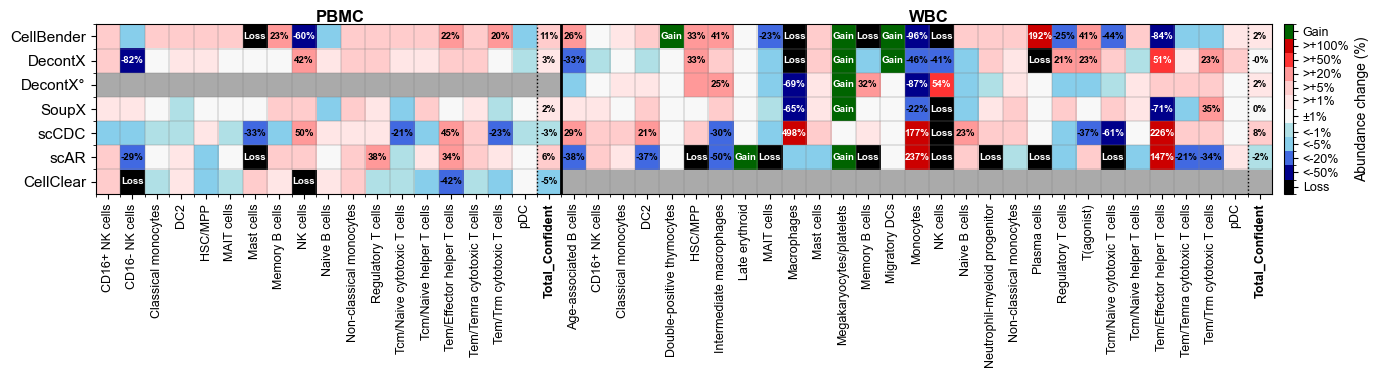

In [10]:
def changes_from_df(df, dataset_label):
    rows = []
    df = df.set_index('Tool')
    uncorr = df.loc['Uncorrected']
    for tool in df.index:
        if tool == 'Uncorrected': continue
        for ct in df.columns:
            u = 0.0 if pd.isna(uncorr.get(ct)) else float(uncorr.get(ct))
            c = 0.0 if pd.isna(df.loc[tool, ct]) else float(df.loc[tool, ct])
            if   u == 0 and c > 0: change, pct = 'Gain',          np.inf
            elif u > 0 and c == 0: change, pct = 'Loss',         -np.inf
            elif abs(c-u)/max(u,1) > 0.05: change, pct = 'Changed (>5%)', (c-u)/max(u,1)*100
            else:                  change, pct = 'Stable',        (c-u)/max(u,1)*100
            rows.append({'Dataset': dataset_label, 'Tool': tool, 'Cell_Type': ct,
                         'Uncorrected': int(u), 'Corrected': int(c),
                         'Change_Type': change, 'Pct_Change': pct})
    return pd.DataFrame(rows)

for d in ['pbmc', 'wbc']:
    datasets[d]['n_confident_fine']['Total_Confident'] = datasets[d]['n_confident_fine'].drop(columns='Tool').sum(axis=1)

changes_fine = pd.concat([
    changes_from_df(datasets['pbmc']['n_confident_fine'], 'PBMC'),
    changes_from_df(datasets['wbc']['n_confident_fine'],  'WBC')
])

method_order_fine = ['CellBender','DecontX','DecontX°','SoupX', 'scCDC','scAR','CellClear']
na_fine = {'PBMC': {'DecontX°'}, 'WBC': {'CellClear'}}
matrix_f, text_f, cts_f, pos_f = build_heatmap(changes_fine, ['pbmc','wbc'], method_order_fine, na_fine)
draw_heatmap(matrix_f, text_f, cts_f, pos_f, method_order_fine, BASE / 'Fig_S_celltype_fine.png', figsize=(14, 4))

In [11]:
rows = []
for dataset_name, data in datasets.items():
    for model_type in (['coarse','fine'] if 'confidence_fine' in data else ['coarse']):
        conf = data['confidence_fine'] if model_type == 'fine' else data['confidence']
        test_tools = (['CellBender','DecontX','DecontX°','SoupX','scCDC']
                      if dataset_name == 'wbc'
                      else ['CellBender','DecontX','SoupX','scCDC'])
        uncorr = conf[conf['Tool'] == 'Uncorrected']['confidence_score'].values

        pairwise = []
        for tool in test_tools:
            tool_data = conf[conf['Tool'] == tool]['confidence_score'].values
            if len(tool_data) == 0:
                continue
            diff = np.median(tool_data) - np.median(uncorr)
            stat, p = mannwhitneyu(tool_data, uncorr, alternative='two-sided')
            pairwise.append({
                'Dataset': dataset_name.upper(),
                'Model': model_type,
                'Tool': tool,
                'N cells': len(tool_data),
                'Median confidence': round(np.median(tool_data), 6),
                'Δ Median': round(diff, 4),
                "Cliff's δ": round(cliffs_delta(stat, len(tool_data), len(uncorr)), 3),
                'p_raw': p
            })

        _, pvals_corr, _, _ = multipletests(
            [r['p_raw'] for r in pairwise], method='bonferroni')
        for r, pc in zip(pairwise, pvals_corr):
            r['p (Bonferroni)'] = f"<0.0001" if pc < 0.0001 else round(pc, 4)
            r['Significance'] = '**' if pc < 0.01 else '*' if pc < 0.05 else 'ns'
            del r['p_raw']
            rows.append(r)

pd.DataFrame(rows)

,Dataset,Model,Tool,N cells,Median confidence,Δ Median,Cliff's δ,p (Bonferroni),Significance
0,PBMC,coarse,CellBender,41428,0.999999,0.0000,0.144,<0.0001,**
1,PBMC,coarse,DecontX,38362,0.999999,0.0000,0.145,<0.0001,**
2,PBMC,coarse,SoupX,37560,0.999998,0.0000,0.073,<0.0001,**
3,PBMC,coarse,scCDC,38436,0.999992,-0.0000,-0.068,<0.0001,**
4,PBMC,fine,CellBender,41428,0.999430,0.0011,0.130,<0.0001,**
5,PBMC,fine,DecontX,38362,0.999064,0.0008,0.073,<0.0001,**
6,PBMC,fine,SoupX,37560,0.998975,0.0007,0.061,<0.0001,**
7,PBMC,fine,scCDC,38436,0.996750,-0.0016,-0.065,<0.0001,**
8,WBC,coarse,CellBender,118951,0.998792,0.0003,0.056,<0.0001,**
9,WBC,coarse,DecontX,121114,0.998734,0.0002,0.022,<0.0001,**
